In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("keplersmachines/kepler-labelled-time-series-data")

print("Path to dataset files:", path)

100%|██████████| 55.9M/55.9M [00:00<00:00, 94.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/keplersmachines/kepler-labelled-time-series-data/versions/3


In [3]:
import pandas as pd

data = pd.read_csv(f"{path}/exoTrain.csv")
data.head()

,LABEL,FLUX.1,FLUX.2,FLUX.3,FLUX.4,FLUX.5,FLUX.6,FLUX.7,FLUX.8,FLUX.9,...,FLUX.3188,FLUX.3189,FLUX.3190,FLUX.3191,FLUX.3192,FLUX.3193,FLUX.3194,FLUX.3195,FLUX.3196,FLUX.3197
0,2,93.85,83.81,20.10,-26.98,-39.56,-124.71,-135.18,-96.27,-79.89,...,-78.07,-102.15,-102.15,25.13,48.57,92.54,39.32,61.42,5.08,-39.54
1,2,-38.88,-33.83,-58.54,-40.09,-79.31,-72.81,-86.55,-85.33,-83.97,...,-3.28,-32.21,-32.21,-24.89,-4.86,0.76,-11.70,6.46,16.00,19.93
2,2,532.64,535.92,513.73,496.92,456.45,466.00,464.50,486.39,436.56,...,-71.69,13.31,13.31,-29.89,-20.88,5.06,-11.80,-28.91,-70.02,-96.67
3,2,326.52,347.39,302.35,298.13,317.74,312.70,322.33,311.31,312.42,...,5.71,-3.73,-3.73,30.05,20.03,-12.67,-8.77,-17.31,-17.35,13.98
4,2,-1107.21,-1112.59,-1118.95,-1095.10,-1057.55,-1034.48,-998.34,-1022.71,-989.57,...,-594.37,-401.66,-401.66,-357.24,-443.76,-438.54,-399.71,-384.65,-411.79,-510.54


In [4]:
print(data.shape)
data.head()

(5087, 3198)


,LABEL,FLUX.1,FLUX.2,FLUX.3,FLUX.4,FLUX.5,FLUX.6,FLUX.7,FLUX.8,FLUX.9,...,FLUX.3188,FLUX.3189,FLUX.3190,FLUX.3191,FLUX.3192,FLUX.3193,FLUX.3194,FLUX.3195,FLUX.3196,FLUX.3197
0,2,93.85,83.81,20.10,-26.98,-39.56,-124.71,-135.18,-96.27,-79.89,...,-78.07,-102.15,-102.15,25.13,48.57,92.54,39.32,61.42,5.08,-39.54
1,2,-38.88,-33.83,-58.54,-40.09,-79.31,-72.81,-86.55,-85.33,-83.97,...,-3.28,-32.21,-32.21,-24.89,-4.86,0.76,-11.70,6.46,16.00,19.93
2,2,532.64,535.92,513.73,496.92,456.45,466.00,464.50,486.39,436.56,...,-71.69,13.31,13.31,-29.89,-20.88,5.06,-11.80,-28.91,-70.02,-96.67
3,2,326.52,347.39,302.35,298.13,317.74,312.70,322.33,311.31,312.42,...,5.71,-3.73,-3.73,30.05,20.03,-12.67,-8.77,-17.31,-17.35,13.98
4,2,-1107.21,-1112.59,-1118.95,-1095.10,-1057.55,-1034.48,-998.34,-1022.71,-989.57,...,-594.37,-401.66,-401.66,-357.24,-443.76,-438.54,-399.71,-384.65,-411.79,-510.54


In [5]:
print(data.columns)

Index(['LABEL', 'FLUX.1', 'FLUX.2', 'FLUX.3', 'FLUX.4', 'FLUX.5', 'FLUX.6',
       'FLUX.7', 'FLUX.8', 'FLUX.9',
       ...
       'FLUX.3188', 'FLUX.3189', 'FLUX.3190', 'FLUX.3191', 'FLUX.3192',
       'FLUX.3193', 'FLUX.3194', 'FLUX.3195', 'FLUX.3196', 'FLUX.3197'],
      dtype='object', length=3198)


In [6]:
data['LABEL'].value_counts()

,count
LABEL,
1,5050
2,37


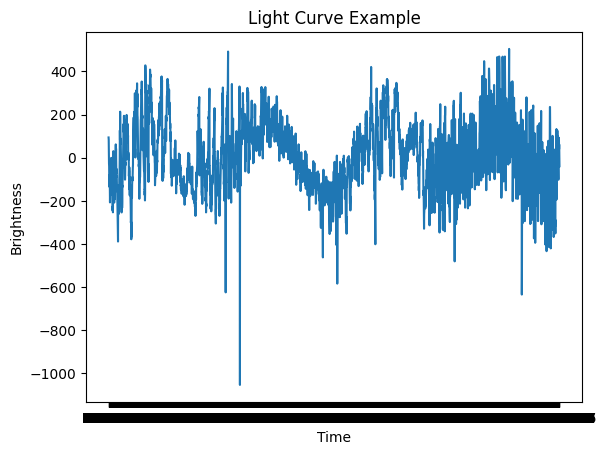

In [7]:
import matplotlib.pyplot as plt

sample = data.iloc[0, 1:]  # skip LABEL column
plt.plot(sample)
plt.title("Light Curve Example")
plt.xlabel("Time")
plt.ylabel("Brightness")
plt.show()

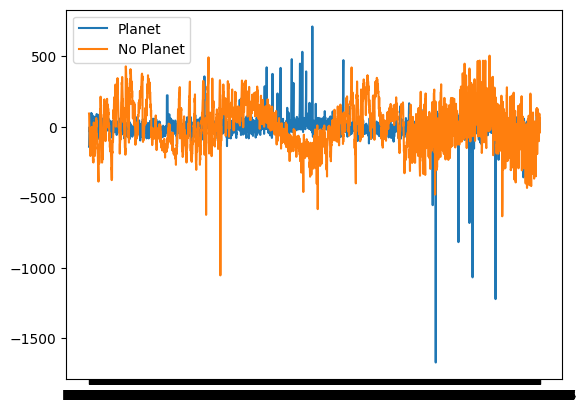

In [8]:
planet = data[data['LABEL'] == 1].iloc[0, 1:]
non_planet = data[data['LABEL'] == 2].iloc[0, 1:]

plt.plot(planet, label="Planet")
plt.plot(non_planet, label="No Planet")
plt.legend()
plt.show()

In [10]:
import pandas as pd

data = pd.read_csv(f"{path}/exoTrain.csv")

In [11]:
import numpy as np

X = data.iloc[:, 1:].values
y = data['LABEL'].values

# Convert labels: 1 → 0, 2 → 1
y = np.where(y == 2, 1, 0)

print("Class distribution:", np.bincount(y))

Class distribution: [5050   37]


In [12]:
from scipy.stats import skew, kurtosis

features = []

for curve in X:
    mean = np.mean(curve)
    std = np.std(curve)
    minimum = np.min(curve)
    depth = mean - minimum
    skewness = skew(curve)
    kurt = kurtosis(curve)

    features.append([mean, std, minimum, depth, skewness, kurt])

features = np.array(features)

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

In [14]:
X_quantum = X_scaled[:, :4]

In [22]:
!pip install --upgrade qiskit qiskit-machine-learning

In [23]:
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit_machine_learning.algorithms import VQC
from qiskit_algorithms.optimizers import COBYLA

In [24]:
feature_map = ZZFeatureMap(feature_dimension=4)
ansatz = RealAmplitudes(num_qubits=4, reps=2)

/tmp/ipykernel_4164/2724411854.py:1: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(feature_dimension=4)
/tmp/ipykernel_4164/2724411854.py:2: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(num_qubits=4, reps=2)


In [25]:
vqc = VQC(
    feature_map=feature_map,
    ansatz=ansatz,
    optimizer=COBYLA(maxiter=100)
)

In [26]:
X_small = X_quantum[:200]
y_small = y[:200]

In [30]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(k_neighbors=1)
X_small_res, y_small_res = smote.fit_resample(X_small, y_small)

print("Before SMOTE:", np.bincount(y_small))
print("After SMOTE:", np.bincount(y_small_res))

Before SMOTE: [163  37]
After SMOTE: [163 163]


In [31]:
from sklearn.model_selection import train_test_split

X_train_q, X_test_q, y_train_q, y_test_q = train_test_split(
    X_small_res, y_small_res,
    test_size=0.2,
    stratify=y_small_res,
    random_state=42
)

In [32]:
vqc.fit(X_train_q, y_train_q)

In [33]:
y_pred_q = vqc.predict(X_test_q)

from sklearn.metrics import classification_report
print(classification_report(y_test_q, y_pred_q))

              precision    recall  f1-score   support

           0       0.60      0.73      0.66        33
           1       0.65      0.52      0.58        33

    accuracy                           0.62        66
   macro avg       0.63      0.62      0.62        66
weighted avg       0.63      0.62      0.62        66

